In [1]:
from pathlib import Path
import sys

repo_root = Path("/Users/josephko/research/cpi-thermo")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    
import pandas as pd
import numpy as np
from pathlib import Path
from typing import Union, Dict, List, Optional
from collections import defaultdict
from parsers.utils import normalize_datetime_utc, si_from_ppmv
import matplotlib.pyplot as plt

In [2]:
# load cpi embeddings timestamps
timestamps_path = '../data/raw/cpi_embeddings_timestamps.csv'
cpi_timestamps = pd.read_csv(timestamps_path)
print(cpi_timestamps.head())
print(cpi_timestamps.shape)

  campaign                 filename             datetime
0  AIRS_II   1114-115708_753_18.png  2003-11-14 11:57:08
1  AIRS_II   1114-115708_753_25.png  2003-11-14 11:57:08
2  AIRS_II   1114-115708_753_35.png  2003-11-14 11:57:08
3  AIRS_II    1114-115708_753_4.png  2003-11-14 11:57:08
4  AIRS_II  1114-115745_814_121.png  2003-11-14 11:57:45
(3200351, 3)


# ATTREX
- Lat (incorrect)
- Lon (N/A)

In [3]:
# load single MMS ICT file and check headers
file_path = Path("/Users/josephko/research/cpi-thermo/data/raw/ATTREX/MMS/MMS-1HZ_GHawk_20131220_R2.ict")
df = pd.read_csv(file_path, skiprows=10, delimiter="\t")
print(df.columns)
print(df)

Index(['0.01, 0.01, 0.01, 0.01, 0.01, 0.001, 0.01, 0.01, 0.00001, 0.00001, 0.1, 0.01, 0.01, 0.01, 0.01                                                                                                          '], dtype='str')
      0.01, 0.01, 0.01, 0.01, 0.01, 0.001, 0.01, 0.01, 0.00001, 0.00001, 0.1, 0.01, 0.01, 0.01, 0.01                                                                                                          
0      -99999, -9999, -9999, -99999, -99999, -99999, ...                                                                                                                                                      
1      P, hPa, Static Pressure                       ...                                                                                                                                                      
2      T, K, Static Temperature                      ...                                                                                                  

In [10]:
# read attrex parquet
attrex_parquet_path = Path("/Users/josephko/research/cpi-thermo/data/out/attrex.parquet")
attrex_df = pd.read_parquet(attrex_parquet_path)
print(attrex_df.columns)
print(attrex_df)

Index(['Timestamp', 'Tair_C', 'Si', 'Lat', 'Lon', 'Alt_m', 'Campaign',
       'source_file'],
      dtype='str')
                              Timestamp  Tair_C  Si       Lat        Lon  \
0      2013-12-20 18:53:51.900000+00:00    6.34 NaN  34.90691 -117.89735   
1      2013-12-20 18:53:52.900000+00:00    6.17 NaN  34.90637 -117.89795   
2      2013-12-20 18:53:53.900000+00:00    6.17 NaN  34.90580 -117.89852   
3      2013-12-20 18:53:54.900000+00:00    6.02 NaN  34.90521 -117.89905   
4      2013-12-20 18:53:55.900000+00:00    5.83 NaN  34.90460 -117.89956   
...                                 ...     ...  ..       ...        ...   
581365 2014-03-15 14:36:11.552000+00:00  -20.22 NaN  35.10626 -117.49871   
581366 2014-03-15 14:36:12.552000+00:00  -20.19 NaN  35.10701 -117.49871   
581367 2014-03-15 14:36:13.552000+00:00  -20.15 NaN  35.10777 -117.49871   
581368 2014-03-15 14:36:14.552000+00:00  -20.13 NaN  35.10853 -117.49871   
581369 2014-03-15 14:36:15.552000+00:00  -20.10 NaN

In [11]:
# print summary of missing data
missing_data_summary = attrex_df.isna().sum()
print("Missing Data Summary:")
print(missing_data_summary)
print(f'Total rows: {len(attrex_df)}')

Missing Data Summary:
Timestamp           0
Tair_C           1742
Si             112451
Lat                 0
Lon                 0
Alt_m               0
Campaign            0
source_file    140494
dtype: int64
Total rows: 581370


compute per-second availability in attrex_df, join to your cpi_timestamps (rounded to nearest second), and report per-variable match percentages.

In [17]:
import pandas as pd

campaign_name = "ATTREX"  # change to the campaign you want

# parse datetimes and round to nearest second
cpi_timestamps["datetime"] = pd.to_datetime(cpi_timestamps["datetime"], utc=True)
cpi_timestamps["dt_s"] = cpi_timestamps["datetime"].dt.round("s")

attrex_df["Timestamp"] = pd.to_datetime(attrex_df["Timestamp"], utc=True)
attrex_df["ts_s"] = attrex_df["Timestamp"].dt.round("s")

cols = ["Tair_C", "Si", "Lat", "Lon", "Alt_m"]

# subset CPI to one campaign only
cpi_campaign = cpi_timestamps[cpi_timestamps["campaign"] == campaign_name].copy()

# per-second CPI counts for that campaign only
cpi_counts = cpi_campaign["dt_s"].value_counts()

# per-second ATTREX availability
tmp = attrex_df[cols + ["ts_s"]].copy()
for c in cols:
    tmp[f"has_{c}"] = tmp[c].notna().astype("uint8")

att_by_sec = tmp.groupby("ts_s")[[f"has_{c}" for c in cols]].max()

# compute match percentage for this campaign only
total_cpi_rows = int(len(cpi_campaign))
rows = []

for c in cols:
    counts_for_att_seconds = cpi_counts.reindex(att_by_sec.index).fillna(0).astype(int)
    matched = int((counts_for_att_seconds.values * att_by_sec[f"has_{c}"].astype(int).values).sum())
    rows.append({
        "variable": c,
        "cpi_rows_with_match": matched,
        "pct_of_campaign_rows": round(100 * matched / total_cpi_rows, 4) if total_cpi_rows else 0.0,
    })

att_all = att_by_sec.all(axis=1).astype(int)
counts_for_att_seconds = cpi_counts.reindex(att_all.index).fillna(0).astype(int)
matched_all = int((counts_for_att_seconds.values * att_all.values).sum())

rows.append({
    "variable": "ALL",
    "cpi_rows_with_match": matched_all,
    "pct_of_campaign_rows": round(100 * matched_all / total_cpi_rows, 4) if total_cpi_rows else 0.0,
})

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

variable  cpi_rows_with_match  pct_of_campaign_rows
  Tair_C               122050               94.5186
      Si               118263               91.5859
     Lat               122050               94.5186
     Lon               122050               94.5186
   Alt_m               122050               94.5186
     ALL               118263               91.5859


In [10]:
attrex_df.columns

Index(['Timestamp', 'Tair_C', 'Si', 'Lat', 'Lon', 'Alt_m', 'Campaign',
       'source_file'],
      dtype='str')

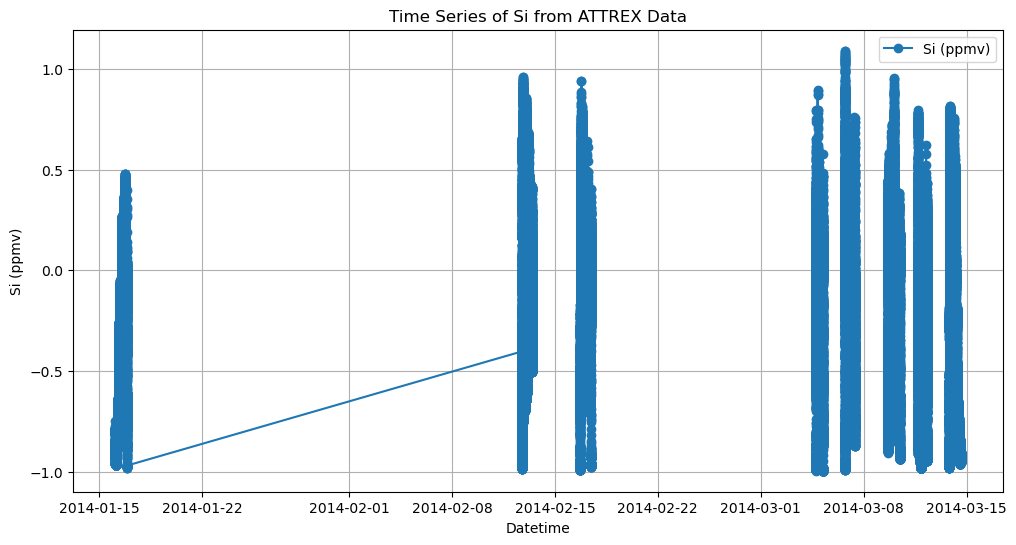

In [11]:
# plot time series of Si for attrex_df
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(attrex_df["Timestamp"], attrex_df["Si"], label="Si (ppmv)", marker="o", linestyle="-")
plt.xlabel("Datetime")
plt.ylabel("Si (ppmv)")
plt.title("Time Series of Si from ATTREX Data")
plt.legend()
plt.grid()
plt.show()

## Water Vapor

In [ ]:
# load NOAA-H2O data
noaa_dir = Path('/Users/josephko/research/cpi-thermo/data/raw/ATTREX/NOAA-H2O')
noaa_files = list(noaa_dir.glob('*R2.ict'))
print(f"Found {len(noaa_files)} NOAA H2O files.")

Found 13 NOAA H2O files.


In [17]:
from pathlib import Path
import pandas as pd


dfs = []

for file in noaa_files:

    # Find the header line dynamically
    with open(file, 'r') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        if line.strip().startswith(
            "NW_UTC_s, NW_WV_H2O_ppm, NW_eTW_H2O_ppm, NW_IWC_ppm, NW_IWC_ugm3"
        ):
            header_line = i
            break

    # Read the file starting from the header
    df = pd.read_csv(
        file,
        skiprows=header_line,
        skipinitialspace=True
    )
    
    # Extract date from the line above the header
    date_line = lines[6].strip()
    year, month, day = [int(x.strip()) for x in date_line.split(',')[:3]]
    flight_date = pd.Timestamp(year=year, month=month, day=day)
    df["Timestamp"] = pd.to_datetime(df["NW_UTC_s"], unit='s', origin=flight_date)

    # Optional: add filename column
    df["source_file"] = file.name
    
    # Replace ICT missing-value flags with NaN
    missing_flags = [-9999.99, -8888.88, -7777.77]
    df = df.replace(missing_flags, np.nan)

    dfs.append(df)

# Concatenate all files
noaa_df = pd.concat(dfs, ignore_index=True)

print(noaa_df.shape)
print(noaa_df.head())

(777204, 7)
   NW_UTC_s  NW_WV_H2O_ppm  NW_eTW_H2O_ppm  NW_IWC_ppm  NW_IWC_ugm3   \
0     78862           3.00            3.00         NaN           NaN   
1     78863           2.52            2.53         NaN           NaN   
2     78864           2.93            2.94         NaN           NaN   
3     78865           2.90            2.92         NaN           NaN   
4     78866           2.82            2.83         NaN           NaN   

            Timestamp                     source_file  
0 2013-02-14 21:54:22  NOAA-H2O_GHawk_20130214_R2.ict  
1 2013-02-14 21:54:23  NOAA-H2O_GHawk_20130214_R2.ict  
2 2013-02-14 21:54:24  NOAA-H2O_GHawk_20130214_R2.ict  
3 2013-02-14 21:54:25  NOAA-H2O_GHawk_20130214_R2.ict  
4 2013-02-14 21:54:26  NOAA-H2O_GHawk_20130214_R2.ict  


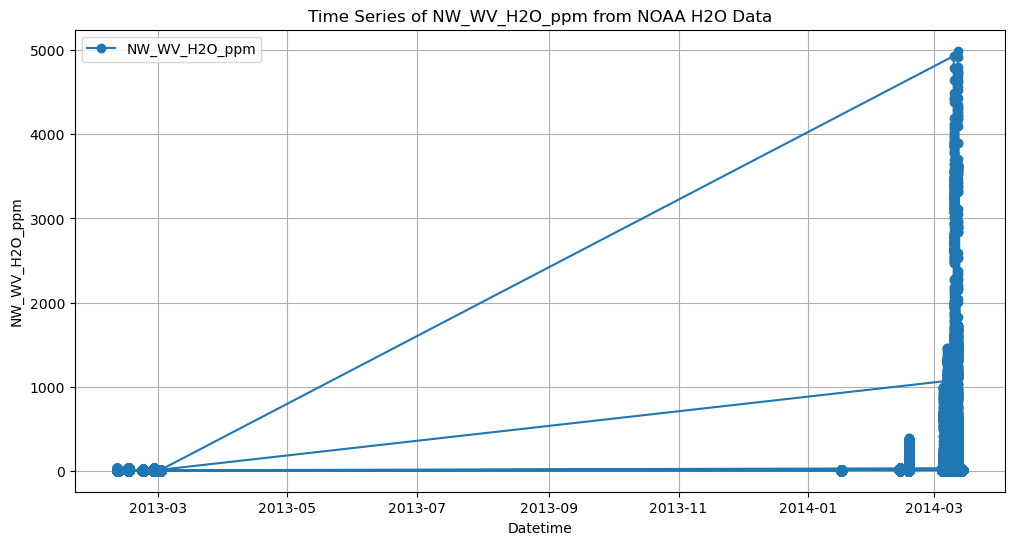

In [18]:
# plot time series of NW_WV_H2O_ppm (water vapor mixing ratio) for noaa_df
plt.figure(figsize=(12, 6))
plt.plot(noaa_df["Timestamp"], noaa_df["NW_WV_H2O_ppm"], label="NW_WV_H2O_ppm", marker="o", linestyle="-")
plt.xlabel("Datetime")
plt.ylabel("NW_WV_H2O_ppm")
plt.title("Time Series of NW_WV_H2O_ppm from NOAA H2O Data")
plt.legend()
plt.grid()
plt.show()

Check what percent of campaign is covered by DLH and NOAA-H2O
- plot 1-d timeline with bar indicating that period is covered by a specific instrument
- used different colors for each instrument

Campaign window: 2011-10-28 17:36:30 to 2014-03-14 14:37:08


,instrument,covered_days,coverage_pct,num_periods
0,DLH-H2O,14.18,1.63,17
1,NOAA-H2O,9.76,1.12,14


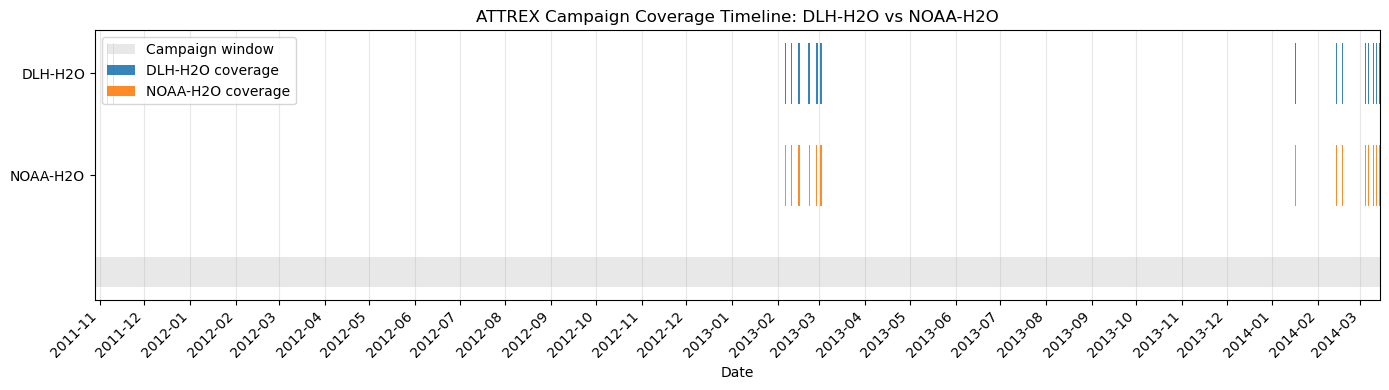

In [7]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def _extract_flight_date(lines, file_name):
    """Return flight start date as pandas.Timestamp."""
    for line in lines[:20]:
        m = re.match(
            r"^\s*(\d{4})\s*,\s*(\d{1,2})\s*,\s*(\d{1,2})\s*,\s*(\d{4})\s*,\s*(\d{1,2})\s*,\s*(\d{1,2})\s*$",
            line.strip(),
        )
        if m:
            year, month, day = map(int, m.group(1, 2, 3))
            return pd.Timestamp(year=year, month=month, day=day)

    # Fallback to YYYYMMDD in filename if needed
    m = re.search(r"(\d{8})", file_name)
    if m:
        return pd.to_datetime(m.group(1), format="%Y%m%d")

    return pd.NaT


def _parse_ict_time_interval(file_path):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    # ICT convention: first value is number of header lines including variable-name row
    header_line_count = int(lines[0].split(",")[0].strip())
    flight_date = _extract_flight_date(lines, file_path.name)
    if pd.isna(flight_date):
        return None

    df = pd.read_csv(
        file_path,
        skiprows=header_line_count - 1,
        skipinitialspace=True,
    )
    df.columns = [c.strip() for c in df.columns]

    # Identify UTC-seconds column
    time_col = None
    preferred = ["Time_UTC", "NW_UTC_s"]
    for col in preferred:
        if col in df.columns:
            time_col = col
            break
    if time_col is None:
        utc_candidates = [c for c in df.columns if "utc" in c.lower()]
        time_col = utc_candidates[0] if utc_candidates else None
    if time_col is None:
        return None

    ts = pd.to_datetime(df[time_col], unit="s", origin=flight_date, errors="coerce")
    ts = ts.dropna()
    if ts.empty:
        return None

    return (ts.min(), ts.max())


def _merge_intervals(intervals):
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x[0])
    merged = [intervals[0]]
    for start, end in intervals[1:]:
        last_start, last_end = merged[-1]
        if start <= last_end:
            merged[-1] = (last_start, max(last_end, end))
        else:
            merged.append((start, end))
    return merged


def _intervals_to_seconds(intervals):
    return sum((end - start).total_seconds() for start, end in intervals)


instrument_dirs = {
    "DLH-H2O": Path("/Users/josephko/research/cpi-thermo/data/raw/ATTREX/DLH-H2O"),
    "NOAA-H2O": Path("/Users/josephko/research/cpi-thermo/data/raw/ATTREX/NOAA-H2O"),
}

instrument_intervals = {}
for instrument, directory in instrument_dirs.items():
    intervals = []
    for f in sorted(directory.glob("*.ict")):
        interval = _parse_ict_time_interval(f)
        if interval is not None:
            intervals.append(interval)
    instrument_intervals[instrument] = _merge_intervals(intervals)

# Campaign window = full span covered by either instrument
all_intervals = [iv for ivs in instrument_intervals.values() for iv in ivs]
campaign_start = min(iv[0] for iv in all_intervals)
campaign_end = max(iv[1] for iv in all_intervals)
campaign_seconds = (campaign_end - campaign_start).total_seconds()

# Compute coverage percentages
coverage_rows = []
for instrument, intervals in instrument_intervals.items():
    covered_seconds = _intervals_to_seconds(intervals)
    covered_days = covered_seconds / (24 * 3600)
    coverage_pct = 100 * covered_seconds / campaign_seconds if campaign_seconds > 0 else 0.0
    coverage_rows.append(
        {
            "instrument": instrument,
            "covered_days": covered_days,
            "coverage_pct": coverage_pct,
            "num_periods": len(intervals),
        }
    )

coverage_df = pd.DataFrame(coverage_rows).sort_values("instrument").reset_index(drop=True)
print("Campaign window:", campaign_start, "to", campaign_end)
coverage_df_display = coverage_df.copy()
coverage_df_display["covered_days"] = coverage_df_display["covered_days"].map(lambda x: round(x, 2))
coverage_df_display["coverage_pct"] = coverage_df_display["coverage_pct"].map(lambda x: round(x, 2))
display(coverage_df_display)

# 1D timeline bars (different colors per instrument)
colors = {"DLH-H2O": "tab:blue", "NOAA-H2O": "tab:orange"}
y_positions = {"DLH-H2O": 20, "NOAA-H2O": 10}
bar_height = 6

fig, ax = plt.subplots(figsize=(14, 4))

# Optional baseline for full campaign extent
ax.broken_barh(
    [(mdates.date2num(campaign_start), mdates.date2num(campaign_end) - mdates.date2num(campaign_start))],
    (2, 3),
    facecolors="lightgray",
    alpha=0.5,
    label="Campaign window",
)

for instrument, intervals in instrument_intervals.items():
    bars = [
        (mdates.date2num(start), mdates.date2num(end) - mdates.date2num(start))
        for start, end in intervals
    ]
    ax.broken_barh(
        bars,
        (y_positions[instrument], bar_height),
        facecolors=colors[instrument],
        alpha=0.9,
        label=f"{instrument} coverage",
    )

ax.set_yticks([y_positions["DLH-H2O"] + bar_height / 2, y_positions["NOAA-H2O"] + bar_height / 2])
ax.set_yticklabels(["DLH-H2O", "NOAA-H2O"])
ax.set_xlabel("Date")
ax.set_title("ATTREX Campaign Coverage Timeline: DLH-H2O vs NOAA-H2O")
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(campaign_start, campaign_end)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# De-duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper left")

plt.tight_layout()
plt.show()

# CRYSTAL-FACE-NASA

Genereate parquet for this campaign:  
`python main.py --campaigns CRYSTAL-FACE-NASA  --output ./data/out/crystal-face-nasa.parquet`

In [53]:
# read campaign parquet
campaign_parquet_path = Path("/Users/josephko/research/cpi-thermo/data/out/crystal-face-nasa.parquet")
df_env = pd.read_parquet(campaign_parquet_path)
print(df_env.columns)
print(df_env)

Index(['Timestamp', 'Tair_C', 'Si', 'Lat', 'Lon', 'Alt_m', 'Campaign',
       'source_file'],
      dtype='str')
                       Timestamp  Tair_C  Si     Lat     Lon  Alt_m  \
0      2002-05-14 15:22:39+00:00     NaN NaN  29.605 -9514.2  0.066   
1      2002-05-14 15:22:40+00:00     NaN NaN  29.606 -9514.1  0.080   
2      2002-05-14 15:22:41+00:00     NaN NaN  29.606 -9514.1  0.096   
3      2002-05-14 15:22:42+00:00     NaN NaN  29.607 -9514.0  0.110   
4      2002-05-14 15:22:43+00:00     NaN NaN  29.607 -9514.0  0.124   
...                          ...     ...  ..     ...     ...    ...   
436754 2002-07-31 18:13:07+00:00     NaN NaN  29.621 -9516.6 -0.025   
436755 2002-07-31 18:13:08+00:00     NaN NaN  29.620 -9516.6 -0.025   
436756 2002-07-31 18:13:09+00:00     NaN NaN  29.620 -9516.6 -0.036   
436757 2002-07-31 18:13:10+00:00     NaN NaN  29.619 -9516.6 -0.035   
436758 2002-07-31 18:13:11+00:00     NaN NaN  29.619 -9516.6 -0.039   

                 Campaign source_f

In [54]:
# Check percent of NaN values in each column
nan_summary = df_env.isna().mean() * 100
nan_summary = nan_summary.round(2)
print("Percentage of NaN values in each column:")
print(nan_summary)  

Percentage of NaN values in each column:
Timestamp       0.00
Tair_C         65.97
Si             65.97
Lat             0.00
Lon             0.00
Alt_m           0.00
Campaign        0.00
source_file     0.00
dtype: float64


In [55]:
df_env['Timestamp'] 

0        2002-05-14 15:22:39+00:00
1        2002-05-14 15:22:40+00:00
2        2002-05-14 15:22:41+00:00
3        2002-05-14 15:22:42+00:00
4        2002-05-14 15:22:43+00:00
                    ...           
436754   2002-07-31 18:13:07+00:00
436755   2002-07-31 18:13:08+00:00
436756   2002-07-31 18:13:09+00:00
436757   2002-07-31 18:13:10+00:00
436758   2002-07-31 18:13:11+00:00
Name: Timestamp, Length: 436759, dtype: datetime64[us, UTC]

In [56]:
campaign_name = "CRYSTAL_FACE_NASA"  # change to the campaign you want

# parse datetimes and round to nearest second
cpi_timestamps["datetime"] = pd.to_datetime(cpi_timestamps["datetime"], utc=True)
cpi_timestamps["dt_s"] = cpi_timestamps["datetime"].dt.round("s")

df_env["Timestamp"] = pd.to_datetime(df_env["Timestamp"], utc=True)
df_env["ts_s"] = df_env["Timestamp"].dt.round("s")

cols = ["Tair_C", "Si", "Lat", "Lon", "Alt_m"]

# subset CPI to one campaign only
cpi_campaign = cpi_timestamps[cpi_timestamps["campaign"] == campaign_name].copy()

# per-second CPI counts for that campaign only
cpi_counts = cpi_campaign["dt_s"].value_counts()

# per-second ENV availability
tmp = df_env[cols + ["ts_s"]].copy()
for c in cols:
    tmp[f"has_{c}"] = tmp[c].notna().astype("uint8")

env_by_sec = tmp.groupby("ts_s")[[f"has_{c}" for c in cols]].max()

# compute match percentage for this campaign only
total_cpi_rows = int(len(cpi_campaign))
rows = []

env_seconds = set(env_by_sec.index)

for c in cols:
    counts_for_env_seconds = cpi_counts.reindex(env_by_sec.index).fillna(0).astype(int)
    matched = int((counts_for_env_seconds.values * env_by_sec[f"has_{c}"].astype(int).values).sum())
    rows.append({
        "variable": c,
        "cpi_rows_with_match": matched,
        "pct_of_campaign_rows": round(100 * matched / total_cpi_rows, 4) if total_cpi_rows else 0.0,
    })

att_all = env_by_sec.all(axis=1).astype(int)
counts_for_att_seconds = cpi_counts.reindex(att_all.index).fillna(0).astype(int)
matched_all = int((counts_for_att_seconds.values * att_all.values).sum())

rows.append({
    "variable": "ALL",
    "cpi_rows_with_match": matched_all,
    "pct_of_campaign_rows": round(100 * matched_all / total_cpi_rows, 4) if total_cpi_rows else 0.0,
})

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

# CPI rows whose rounded timestamp has no exact rounded-second ENV match
cpi_campaign["dt_s"] = pd.to_datetime(cpi_campaign["datetime"], utc=True).dt.round("s")
cpi_without_env = cpi_campaign[~cpi_campaign["dt_s"].isin(env_seconds)].copy()

print(f"\nCPI rows without matching ENV seconds: {len(cpi_without_env)}")
if not cpi_without_env.empty:
    print("\nExample unmatched CPI rows:")
    cols_to_show = [c for c in ["datetime", "dt_s", "campaign"] if c in cpi_without_env.columns]
    print(cpi_without_env[cols_to_show].head(20).to_string(index=False))

    print("\nUnique unmatched CPI seconds (first 20):")
    unmatched_seconds = sorted(cpi_without_env["dt_s"].dropna().unique())
    for ts in unmatched_seconds[:20]:
        print(f"  {ts}")
else:
    print("All CPI rows have a matching ENV second.")

variable  cpi_rows_with_match  pct_of_campaign_rows
  Tair_C                13012               16.6496
      Si                13012               16.6496
     Lat                77470               99.1273
     Lon                77470               99.1273
   Alt_m                77470               99.1273
     ALL                13012               16.6496

CPI rows without matching ENV seconds: 682

Example unmatched CPI rows:
                 datetime                      dt_s          campaign
2002-07-11 15:48:22+00:00 2002-07-11 15:48:22+00:00 CRYSTAL_FACE_NASA
2002-07-11 15:51:08+00:00 2002-07-11 15:51:08+00:00 CRYSTAL_FACE_NASA
2002-07-11 15:51:08+00:00 2002-07-11 15:51:08+00:00 CRYSTAL_FACE_NASA
2002-07-11 15:51:08+00:00 2002-07-11 15:51:08+00:00 CRYSTAL_FACE_NASA
2002-07-11 15:51:08+00:00 2002-07-11 15:51:08+00:00 CRYSTAL_FACE_NASA
2002-07-19 17:48:17+00:00 2002-07-19 17:48:17+00:00 CRYSTAL_FACE_NASA
2002-07-19 17:48:24+00:00 2002-07-19 17:48:24+00:00 CRYSTAL_FACE_NASA
200

GPS data is available for most CPI timestamps, but Si and Temp only available for ~16% 

In [57]:
# seconds where Si exists in the ENV data
si_seconds = env_by_sec.index[env_by_sec["has_Si"] == 1]

# CPI rows whose rounded timestamp has no matching Si second
cpi_without_si = cpi_campaign[~cpi_campaign["dt_s"].isin(si_seconds)].copy()

print(f"CPI rows without matching Si seconds: {len(cpi_without_si)}")
if not cpi_without_si.empty:
    print(cpi_without_si[["datetime", "dt_s", "campaign"]].head(20).to_string(index=False))

CPI rows without matching Si seconds: 65140
                 datetime                      dt_s          campaign
2002-07-09 15:32:38+00:00 2002-07-09 15:32:38+00:00 CRYSTAL_FACE_NASA
2002-07-09 15:32:38+00:00 2002-07-09 15:32:38+00:00 CRYSTAL_FACE_NASA
2002-07-09 15:33:45+00:00 2002-07-09 15:33:45+00:00 CRYSTAL_FACE_NASA
2002-07-09 15:33:45+00:00 2002-07-09 15:33:45+00:00 CRYSTAL_FACE_NASA
2002-07-09 15:33:45+00:00 2002-07-09 15:33:45+00:00 CRYSTAL_FACE_NASA
2002-07-09 15:34:11+00:00 2002-07-09 15:34:11+00:00 CRYSTAL_FACE_NASA
2002-07-09 15:34:11+00:00 2002-07-09 15:34:11+00:00 CRYSTAL_FACE_NASA
2002-07-09 15:34:11+00:00 2002-07-09 15:34:11+00:00 CRYSTAL_FACE_NASA
2002-07-09 15:34:11+00:00 2002-07-09 15:34:11+00:00 CRYSTAL_FACE_NASA
2002-07-09 15:34:11+00:00 2002-07-09 15:34:11+00:00 CRYSTAL_FACE_NASA
2002-07-09 15:34:18+00:00 2002-07-09 15:34:18+00:00 CRYSTAL_FACE_NASA
2002-07-09 15:34:18+00:00 2002-07-09 15:34:18+00:00 CRYSTAL_FACE_NASA
2002-07-09 15:34:18+00:00 2002-07-09 15:34:18+

In [58]:
# Table of number of samples from each day from cpi_without_si
cpi_without_si["date"] = cpi_without_si["datetime"].dt.date
daily_counts = cpi_without_si["date"].value_counts().sort_index()
print("\nNumber of CPI samples without matching Si per day:")
print(daily_counts.to_string())


Number of CPI samples without matching Si per day:
date
2002-07-09      919
2002-07-11     7330
2002-07-16    14785
2002-07-19     1589
2002-07-21     6155
2002-07-23     2396
2002-07-26        9
2002-07-28    15470
2002-07-29    16487


Target day: 2002-07-16
CPI rows on target day: 17803
CPI rows without matching Si on target day: 14785
Unique overlapping seconds: 96

First 20 CPI rows without matching Si:
                 datetime                      dt_s          campaign
2002-07-16 18:12:53+00:00 2002-07-16 18:12:53+00:00 CRYSTAL_FACE_NASA
2002-07-16 18:12:53+00:00 2002-07-16 18:12:53+00:00 CRYSTAL_FACE_NASA
2002-07-16 18:12:53+00:00 2002-07-16 18:12:53+00:00 CRYSTAL_FACE_NASA
2002-07-16 18:12:53+00:00 2002-07-16 18:12:53+00:00 CRYSTAL_FACE_NASA
2002-07-16 19:40:14+00:00 2002-07-16 19:40:14+00:00 CRYSTAL_FACE_NASA
2002-07-16 19:40:14+00:00 2002-07-16 19:40:14+00:00 CRYSTAL_FACE_NASA
2002-07-16 19:40:14+00:00 2002-07-16 19:40:14+00:00 CRYSTAL_FACE_NASA
2002-07-16 19:40:14+00:00 2002-07-16 19:40:14+00:00 CRYSTAL_FACE_NASA
2002-07-16 19:40:14+00:00 2002-07-16 19:40:14+00:00 CRYSTAL_FACE_NASA
2002-07-16 19:40:14+00:00 2002-07-16 19:40:14+00:00 CRYSTAL_FACE_NASA
2002-07-16 19:40:14+00:00 2002-07-16 19:40:14+00:00 CRYS

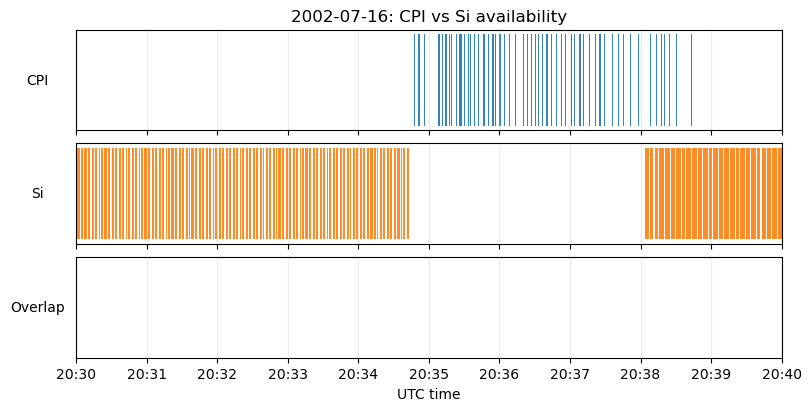

In [66]:
import matplotlib.dates as mdates

target_day = pd.Timestamp("2002-07-16").date()

# CPI rows on the target day
cpi_day = cpi_campaign[cpi_campaign["dt_s"].dt.date == target_day].copy()
cpi_day_missing_si = cpi_day[~cpi_day["dt_s"].isin(si_seconds)].copy()

# Si seconds on the target day
si_day_seconds = pd.DatetimeIndex(
    pd.to_datetime([ts for ts in si_seconds if ts.date() == target_day])
)

# Overlap seconds
cpi_day_seconds = pd.DatetimeIndex(cpi_day["dt_s"].dropna().unique())
overlap_seconds = cpi_day_seconds.intersection(si_day_seconds)

print(f"Target day: {target_day}")
print(f"CPI rows on target day: {len(cpi_day)}")
print(f"CPI rows without matching Si on target day: {len(cpi_day_missing_si)}")
print(f"Unique overlapping seconds: {len(overlap_seconds)}")

if not cpi_day_missing_si.empty:
    print("\nFirst 20 CPI rows without matching Si:")
    print(cpi_day_missing_si[["datetime", "dt_s", "campaign"]].head(20).to_string(index=False))


def seconds_to_intervals(times):
    times = pd.DatetimeIndex(sorted(pd.to_datetime(times)))
    if len(times) == 0:
        return []
    intervals = []
    start = times[0]
    prev = times[0]
    for ts in times[1:]:
        if ts - prev > pd.Timedelta(seconds=1):
            intervals.append((start, prev + pd.Timedelta(seconds=1)))
            start = ts
        prev = ts
    intervals.append((start, prev + pd.Timedelta(seconds=1)))
    return intervals


cpi_intervals = seconds_to_intervals(cpi_day_seconds)
si_intervals = seconds_to_intervals(si_day_seconds)
overlap_intervals = seconds_to_intervals(overlap_seconds)

fig, axes = plt.subplots(3, 1, figsize=(8, 4), sharex=True, constrained_layout=True)

panels = [
    (axes[0], cpi_intervals, "tab:blue", "CPI"),
    (axes[1], si_intervals, "tab:orange", "Si"),
    (axes[2], overlap_intervals, "tab:green", "Overlap"),
]

for ax, intervals, color, label in panels:
    bars = [
        (mdates.date2num(start), mdates.date2num(end) - mdates.date2num(start))
        for start, end in intervals
    ]
    if bars:
        ax.broken_barh(bars, (0.2, 0.6), facecolors=color, alpha=0.9)
    ax.set_yticks([])
    ax.set_ylabel(label, rotation=0, labelpad=28, va="center")
    ax.grid(axis="x", alpha=0.25)

axes[-1].xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[-1].set_xlim(
    pd.Timestamp(f"{target_day} 20:30:00", tz="UTC"),
    pd.Timestamp(f"{target_day} 20:40:00", tz="UTC"),
)
axes[0].set_title("2002-07-16: CPI vs Si availability")
axes[-1].set_xlabel("UTC time")

plt.show()

In [ ]:
import pandas as pd

campaign_cpi = "CRYSTAL_FACE_NASA"
campaign_env = "CRYSTAL-FACE-NASA"

# Filter to the campaign first
cpi_campaign = cpi_timestamps[cpi_timestamps["campaign"] == campaign_cpi].copy()
env_campaign = df_env[df_env["Campaign"] == campaign_env].copy()

if cpi_campaign.empty:
    raise ValueError(f"No CPI rows found for {campaign_cpi}")
if env_campaign.empty:
    raise ValueError(f"No ENV rows found for {campaign_env}")

# Parse timestamps
cpi_campaign["datetime"] = pd.to_datetime(cpi_campaign["datetime"], utc=True)
env_campaign["Timestamp"] = pd.to_datetime(env_campaign["Timestamp"], utc=True)
env_campaign["ts_s"] = env_campaign["Timestamp"].dt.round("s")

# Sample one random CPI timestamp
sample_row = cpi_campaign.sample(1).iloc[0]
sample_time = sample_row["datetime"]
sample_time_s = sample_time.round("s")

print(f"Random CPI timestamp: {sample_time}")
print(f"Rounded to second:     {sample_time_s}")

# Exact nearest-second match in env
exact_match = env_campaign[env_campaign["ts_s"] == sample_time_s].copy()

if not exact_match.empty:
    print(f"\nExact match found at nearest second ({len(exact_match)} row(s)):")
    print(exact_match[["Timestamp", "Tair_C", "Si", "Lat", "Lon", "Alt_m", "source_file"]])
else:
    print("\nNo exact match at the nearest second.")

    # Closest env timestamp by absolute time difference
    env_campaign["time_diff_s"] = (env_campaign["Timestamp"] - sample_time).dt.total_seconds().abs()
    closest_row = env_campaign.loc[env_campaign["time_diff_s"].idxmin()]

    print("Closest env timestamp:")
    print(
        closest_row[
            [
                "Timestamp",
                "time_diff_s",
                "Tair_C",
                "Si",
                "Lat",
                "Lon",
                "Alt_m",
                "source_file",
            ]
        ]
    )
    print(f"Time difference: {closest_row['time_diff_s']:.3f} seconds")

Random CPI timestamp: 2002-07-29 19:23:36+00:00
Rounded to second:     2002-07-29 19:23:36+00:00

No exact match at the nearest second.
Closest env timestamp:
Timestamp      2002-07-28 23:15:03+00:00
time_diff_s                      72513.0
Tair_C                            -58.22
Si                                0.2961
Lat                               26.304
Lon                              -8246.9
Alt_m                             12.177
source_file              JW20020728.WB57
Name: 148609, dtype: object
Time difference: 72513.000 seconds


Temp is from MMS data though, so should nearly complete. Check availability from other water vapor instrument.

# IPHEX
Genereate parquet for this campaign:  
`python main.py --campaigns IPHEX  --output ./data/out/iphex.parquet`

In [5]:
# read campaign parquet
campaign_parquet_path = Path("/Users/josephko/research/cpi-thermo/data/out/iphex.parquet")
df_env = pd.read_parquet(campaign_parquet_path)
print(df_env.columns)
print(df_env)

Index(['Timestamp', 'Tair_C', 'Si', 'Lat', 'Lon', 'Alt_m', 'Campaign',
       'source_file'],
      dtype='str')
                              Timestamp   Tair_C        Si        Lat  \
0      2014-03-06 17:45:38.860000+00:00  -1.4953       NaN        NaN   
1      2014-03-06 17:45:39.860000+00:00  -1.4683       NaN        NaN   
2      2014-03-06 17:45:40.860000+00:00  -1.4455       NaN        NaN   
3      2014-03-06 17:45:41.860000+00:00  -1.4300       NaN        NaN   
4      2014-03-06 17:45:42.860000+00:00  -1.4275       NaN        NaN   
...                                 ...      ...       ...        ...   
287595 2014-06-13 23:39:36.930000+00:00  22.3948 -0.676766  47.949342   
287596 2014-06-13 23:39:37.930000+00:00  22.4392 -0.674037  47.949369   
287597 2014-06-13 23:39:38.930000+00:00  22.4648 -0.668648  47.949396   
287598 2014-06-13 23:39:39.930000+00:00  22.4920 -0.673913  47.949425   
287599 2014-06-13 23:39:40.930000+00:00  22.5105 -0.672465  47.949455   

          

In [6]:
# Check percent of NaN values in each column
nan_summary = df_env.isna().mean() * 100
nan_summary = nan_summary.round(2)
print("Percentage of NaN values in each column:")
print(nan_summary)  

Percentage of NaN values in each column:
Timestamp       0.00
Tair_C          0.37
Si             32.92
Lat             0.58
Lon             0.58
Alt_m           0.58
Campaign        0.00
source_file     0.00
dtype: float64


In [8]:
# return periods of missing data for Si with timestamps
# optional: keep only long gaps
min_missing_rows = 10          # change this to 1 if you want every gap
min_missing_frac = 0.80        # only report gaps where at least 80% of rows in the interval are missing

df = df_env.sort_values("Timestamp").reset_index(drop=True).copy()
missing = df["Si"].isna().to_numpy()

missing_periods = []
start = None

for i, is_missing in enumerate(missing):
    if is_missing and start is None:
        start = i
    elif not is_missing and start is not None:
        end = i - 1
        missing_periods.append((start, end))
        start = None

if start is not None:
    missing_periods.append((start, len(df) - 1))

print("Missing periods for Si:")

for start_idx, end_idx in missing_periods:
    block = df.iloc[start_idx:end_idx + 1]
    n_rows = len(block)
    n_missing = block["Si"].isna().sum()
    missing_frac = n_missing / n_rows if n_rows else 0.0

    if n_rows >= min_missing_rows and missing_frac >= min_missing_frac:
        start_ts = block["Timestamp"].iloc[0]
        end_ts = block["Timestamp"].iloc[-1]
        print(
            f"  rows {start_idx}-{end_idx} | "
            f"{start_ts} to {end_ts} | "
            f"{n_missing}/{n_rows} missing ({missing_frac:.1%})"
        )

Missing periods for Si:
  rows 0-10371 | 2014-03-06 17:45:38.860000+00:00 to 2014-04-22 21:05:40.800000+00:00 | 10372/10372 missing (100.0%)
  rows 10495-10507 | 2014-04-22 21:07:44.800000+00:00 to 2014-04-22 21:07:56.800000+00:00 | 13/13 missing (100.0%)
  rows 13434-56994 | 2014-04-29 15:21:06.540000+00:00 to 2014-05-12 19:01:40.530000+00:00 | 43561/43561 missing (100.0%)
  rows 65263-68572 | 2014-05-15 15:16:30.490000+00:00 to 2014-05-15 16:11:39.490000+00:00 | 3310/3310 missing (100.0%)
  rows 70148-70791 | 2014-05-15 16:37:55.490000+00:00 to 2014-05-15 16:48:38.490000+00:00 | 644/644 missing (100.0%)
  rows 71033-71043 | 2014-05-16 10:18:29.800000+00:00 to 2014-05-16 10:18:39.800000+00:00 | 11/11 missing (100.0%)
  rows 80167-82658 | 2014-05-16 13:45:50.440000+00:00 to 2014-05-16 14:27:21.440000+00:00 | 2492/2492 missing (100.0%)
  rows 90379-91883 | 2014-05-16 17:38:35.210000+00:00 to 2014-05-16 18:03:39.210000+00:00 | 1505/1505 missing (100.0%)
  rows 92004-92043 | 2014-05-16 18

# ARM
Genereate parquet for this campaign:  
`python main.py --campaigns ARM  --output ./data/out/arm.parquet`

In [22]:
# read campaign parquet
campaign_parquet_path = Path("/Users/josephko/research/cpi-thermo/data/out/arm.parquet")
df_env = pd.read_parquet(campaign_parquet_path)
print(df_env.columns)

# Check percent of NaN values in each column
nan_summary = df_env.isna().mean() * 100
nan_summary = nan_summary.round(2)
print("Percentage of NaN values in each column:")
print(nan_summary)  

Index(['Timestamp', 'Tair_C', 'Si', 'Lat', 'Lon', 'Alt_m', 'Campaign',
       'source_file'],
      dtype='str')
Percentage of NaN values in each column:
Timestamp      0.0
Tair_C         0.0
Si             0.0
Lat            0.0
Lon            0.0
Alt_m          0.0
Campaign       0.0
source_file    0.0
dtype: float64


In [23]:
campaign_name = "ARM"  # change to campaign you want to analyze

# Filter to campaign
cpi_campaign = cpi_timestamps[cpi_timestamps["campaign"] == campaign_name].copy()
env_campaign = df_env[df_env["Campaign"] == campaign_name].copy()

if cpi_campaign.empty or env_campaign.empty:
    print(f"Error: No data found for campaign {campaign_name}")
else:
    # Parse datetimes
    cpi_campaign["datetime"] = pd.to_datetime(cpi_campaign["datetime"], utc=True)
    env_campaign["Timestamp"] = pd.to_datetime(env_campaign["Timestamp"], utc=True)
    
    # Get time ranges
    cpi_start = cpi_campaign["datetime"].min()
    cpi_end = cpi_campaign["datetime"].max()
    env_start = env_campaign["Timestamp"].min()
    env_end = env_campaign["Timestamp"].max()
    
    # Calculate overlap
    overlap_start = max(cpi_start, env_start)
    overlap_end = min(cpi_end, env_end)
    
    cpi_duration = (cpi_end - cpi_start).total_seconds()
    env_duration = (env_end - env_start).total_seconds()
    overlap_duration = (overlap_end - overlap_start).total_seconds() if overlap_end >= overlap_start else 0
    
    cpi_rows_in_overlap = len(cpi_campaign[
        (cpi_campaign["datetime"] >= overlap_start) & 
        (cpi_campaign["datetime"] <= overlap_end)
    ])
    
    env_rows_in_overlap = len(env_campaign[
        (env_campaign["Timestamp"] >= overlap_start) & 
        (env_campaign["Timestamp"] <= overlap_end)
    ])
    
    # Print diagnostics
    print(f"Campaign: {campaign_name}")
    print(f"\nCPI Dataset:")
    print(f"  Time range: {cpi_start} to {cpi_end}")
    print(f"  Duration: {cpi_duration / 3600:.2f} hours")
    print(f"  Total rows: {len(cpi_campaign)}")
    
    print(f"\nEnvironmental Dataset:")
    print(f"  Time range: {env_start} to {env_end}")
    print(f"  Duration: {env_duration / 3600:.2f} hours")
    print(f"  Total rows: {len(env_campaign)}")
    
    print(f"\nOverlap:")
    print(f"  Overlap range: {overlap_start} to {overlap_end}")
    print(f"  Overlap duration: {overlap_duration / 3600:.2f} hours")
    if cpi_duration > 0:
        print(f"  % of CPI covered by ENV: {100 * overlap_duration / cpi_duration:.1f}%")
    if env_duration > 0:
        print(f"  % of ENV covering CPI: {100 * overlap_duration / env_duration:.1f}%")
    print(f"  CPI rows in overlap: {cpi_rows_in_overlap} ({100 * cpi_rows_in_overlap / len(cpi_campaign):.1f}%)")
    print(f"  ENV rows in overlap: {env_rows_in_overlap} ({100 * env_rows_in_overlap / len(env_campaign):.1f}%)")
    
    if overlap_duration <= 0:
        print("\n⚠️  WARNING: No temporal overlap between CPI and ENV datasets!")

Campaign: ARM

CPI Dataset:
  Time range: 2000-03-06 20:20:27+00:00 to 2000-03-20 15:36:38+00:00
  Duration: 331.27 hours
  Total rows: 295703

Environmental Dataset:
  Time range: 2000-03-03 16:55:20+00:00 to 2000-03-21 19:52:41.750000+00:00
  Duration: 434.96 hours
  Total rows: 567760

Overlap:
  Overlap range: 2000-03-06 20:20:27+00:00 to 2000-03-20 15:36:38+00:00
  Overlap duration: 331.27 hours
  % of CPI covered by ENV: 100.0%
  % of ENV covering CPI: 76.2%
  CPI rows in overlap: 295703 (100.0%)
  ENV rows in overlap: 429040 (75.6%)
